# Maven CRM — simple opportunity-level Won/Lost evaluation

**Question:** can information available at engagement predict whether an opportunity will eventually be Won or Lost?

**Data → Features → Split → Train → Predict → Evaluate → Compare.** One row per closed opportunity; **Won = 1**, **Lost = 0**. Open opportunities are unlabelled, not losses.

This is the simplified evaluation entry point. The [original audit](03_maven_dataset_audit.ipynb), [earlier chronological experiments](04_maven_feature_engineering.ipynb), and [their results](maven_evaluation_summary.json) remain unchanged. Reused logic: the reference-supported `GTXPro` → `GTX Pro` correction, unique opportunity keys, and validated many-to-one joins. No snapshots, historical outcome features, or hyperparameter search.

Three separate questions:
- **A — random opportunities:** is there learnable signal within this extract?
- **B — engagement chronology:** does it transfer to later engagement cohorts?
- **C — account groups:** does it transfer to companies excluded from training?

**Scope of evidence:** Maven describes a fictitious computer-hardware company ([source](https://mavenanalytics.io/data-playground/crm-sales-opportunities)). Account/product/team reference tables are undated snapshots: their availability at engagement is a modelling assumption, not verified historical fact. Only resolved outcomes are evaluated. This is exploratory follow-up on an already-inspected dataset, not a new external holdout.

## 1. Load the Maven tables
Run top to bottom in the `opportunity-scoring` Python kernel. All paths work from the repository or its notebooks folder. Package versions and source hashes are recorded; no dependency on another notebook's variables.

In [25]:
from pathlib import Path
from importlib.metadata import version
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datasets").is_dir())
DATA = ROOT / "datasets" / "CRM+Sales+Opportunities"
OUTPUT = ROOT / "notebooks" / "maven_simple_results"
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 85)

names = ["sales_pipeline", "accounts", "products", "sales_teams", "data_dictionary"]
tables = {name: pd.read_csv(DATA / f"{name}.csv", keep_default_na=False, na_values=[""]) for name in names}
source_hashes = {name: hashlib.sha256((DATA / f"{name}.csv").read_bytes()).hexdigest() for name in names}
previous_files = ["03_maven_dataset_audit.ipynb", "04_maven_feature_engineering.ipynb", "maven_evaluation_summary.json"]
previous_hashes = {name: hashlib.sha256((ROOT / "notebooks" / name).read_bytes()).hexdigest() for name in previous_files}
packages = {name: version(name) for name in ["numpy", "pandas", "matplotlib", "scikit-learn", "xgboost-cpu", "ipykernel"]}
print("Python:", sys.version.split()[0], "| kernel:", sys.executable)
print("Packages:", packages)
display(pd.DataFrame([
    {"table": name, "rows": len(table), "columns": len(table.columns), "exact_duplicates": table.duplicated().sum()}
    for name, table in tables.items()
]).set_index("table"))
display(tables["data_dictionary"])
display(tables["sales_pipeline"].head(3))

Python: 3.12.3 | kernel: /home/emmanuel/.venvs/opportunity-scoring/bin/python
Packages: {'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'scikit-learn': '1.9.1', 'xgboost-cpu': '3.4.1', 'ipykernel': '7.4.0'}


,rows,columns,exact_duplicates
table,,,
sales_pipeline,8800,8,0
accounts,85,7,0
products,7,3,0
sales_teams,35,3,0
data_dictionary,21,3,0


,Table,Field,Description
0,accounts,account,Company name
1,accounts,sector,Industry
2,accounts,year_established,Year Established
3,accounts,revenue,Annual revenue (in millions of USD)
4,accounts,employees,Number of employees
5,accounts,office_location,Headquarters
6,accounts,subsidiary_of,Parent company
7,products,product,Product name
8,products,series,Product series
9,products,sales_price,Suggested retail price


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0


## 2. Opportunity population
Exact duplicate rows may be removed, but conflicting rows for one opportunity must not be arbitrarily selected. The current Maven file has neither. Keep all valid Won/Lost rows; do not require a win value or treat an open opportunity as Lost. Dates below are audit/split metadata, never outcome predictors.

In [26]:
pipeline = tables["sales_pipeline"].drop_duplicates().copy()
assert pipeline["opportunity_id"].notna().all()
assert pipeline["opportunity_id"].is_unique, "Stop: investigate repeated opportunity IDs."
pipeline["deal_stage"] = pipeline["deal_stage"].str.strip().str.title()
assert pipeline["deal_stage"].isin(["Won", "Lost", "Engaging", "Prospecting"]).all()
for column in ["engage_date", "close_date"]:
    pipeline[column] = pd.to_datetime(pipeline[column], format="%Y-%m-%d")

closed = pipeline.loc[pipeline["deal_stage"].isin(["Won", "Lost"])].copy()
closed["target"] = closed["deal_stage"].map({"Won": 1, "Lost": 0}).astype(int)
open_opportunities = pipeline.loc[~pipeline["deal_stage"].isin(["Won", "Lost"])].copy()
population = {
    "source_rows": len(tables["sales_pipeline"]),
    "exact_duplicates_removed": len(tables["sales_pipeline"]) - len(pipeline),
    "closed_opportunities": len(closed),
    "unlabelled_open": len(open_opportunities),
    "wins": int(closed["target"].sum()),
    "losses": int(closed["target"].eq(0).sum()),
    "won_prevalence": float(closed["target"].mean()),
}
display(pd.Series(population, name="value").to_frame())
print("Closed rows missing split/group metadata:")
display(closed[["account", "engage_date", "close_date"]].isna().sum().to_frame("missing"))
assert not closed["close_date"].lt(closed["engage_date"]).any()

,value
source_rows,8800.000000
exact_duplicates_removed,0.000000
closed_opportunities,6711.000000
unlabelled_open,2089.000000
wins,4238.000000
losses,2473.000000
won_prevalence,0.631501


Closed rows missing split/group metadata:


,missing
account,0
engage_date,0
close_date,0


## 3. Join only relevant reference data
Use the existing audit's verified product correction and `many_to_one` joins. Do not discard a closed opportunity merely because an attribute is missing. Sales-team data are joined only for a separately labelled assignment sensitivity check. The observed agent may have changed before closure; initial assignment is not documented.

The dictionary defines **revenue in millions of USD** and `sales_price` as **suggested retail price**, not closing value. No reference table has effective dates.

In [27]:
accounts, products, teams = [tables[name].copy() for name in ["accounts", "products", "sales_teams"]]
for table, key in [(accounts, "account"), (products, "product"), (teams, "sales_agent")]:
    assert table[key].notna().all() and table[key].is_unique

assert [p for p in products["product"] if p.replace(" ", "") == "GTXPro"] == ["GTX Pro"]
print("Product correction on closed rows:", closed["product"].eq("GTXPro").sum())
closed["product"] = closed["product"].replace({"GTXPro": "GTX Pro"})
joined = closed.copy()
join_rows = []
for reference, key in [(accounts, "account"), (products, "product"), (teams, "sales_agent")]:
    join_rows.append({
        "key": key,
        "missing_keys": int(joined[key].isna().sum()),
        "unmatched_nonmissing": int((joined[key].notna() & ~joined[key].isin(reference[key])).sum()),
    })
    joined = joined.merge(reference, on=key, how="left", validate="many_to_one")
assert len(joined) == len(closed) and joined["opportunity_id"].is_unique
join_audit = pd.DataFrame(join_rows)
display(join_audit)
print("Joined shape:", joined.shape)
print("Founding year after engagement (age will not be a predictor):",
      joined["year_established"].gt(joined["engage_date"].dt.year).sum())

Product correction on closed rows: 1147


,key,missing_keys,unmatched_nonmissing
0,account,0,0
1,product,0,0
2,sales_agent,0,0


Joined shape: (6711, 19)
Founding year after engagement (age will not be a predictor): 5


## 4. Feature contract — fixed before modelling
**Core = sector + employee band + revenue band + subsidiary indicator.** Use fixed business bands, not quantiles or outcome-optimized boundaries. Drop exact financials because the original audit found that each identifies all 85 accounts.

Keep geography and age out of this deliberately small baseline: most non-US countries identify one account, and founding dates include inconsistencies. Product is a separate, defensible offer characteristic, not a company identifier. Product already determines series and list price, so adding all three is unnecessary.

The calendar comparison adds engagement **month and quarter**, not year. Sales assignment is a separate sensitivity experiment with unverified initial-assignment timing; its performance cannot rescue a weak general-characteristic model. No outcome histories are created.

In [28]:
feature_contract = pd.DataFrame([
    ("sector", "accounts", "Keep: core", "Industry; normalize the documented technology spelling."),
    ("employee_band", "accounts.employees", "Keep: core", "Fixed counts: <250, 250–999, 1,000–4,999, >=5,000."),
    ("revenue_band", "accounts.revenue", "Keep: core", "Fixed USD millions: <100, 100–999, 1,000–4,999, >=5,000."),
    ("is_subsidiary", "accounts.subsidiary_of", "Keep: core", "Recorded parent: yes/no only; never parent identity."),
    ("product", "sales_pipeline + products", "Keep: product experiment", "One of seven offers, assumed known at engagement."),
    ("engagement_month / quarter", "sales_pipeline.engage_date", "Keep: calendar experiment", "Known at engagement; not evidence of repeatable seasonality."),
    ("sales_agent / regional_office", "sales_pipeline + sales_teams", "Keep: assignment experiment", "Separate identity-sensitive test; initial assignment unverified."),
    ("account / opportunity_id", "sales_pipeline", "Drop from predictors", "Grouping/uniqueness metadata only; no company memorisation by name."),
    ("revenue / employees / subsidiary_of", "accounts", "Drop raw values", "Exact financials and parent names can identify companies."),
    ("office_location / year_established / age", "accounts", "Drop", "Sparse geography, imperfect founding years; keep core small."),
    ("series / sales_price", "products", "Drop", "Determined by product; redundant. List price is not closing value."),
    ("manager", "sales_teams", "Drop", "Additional identity proxy; unnecessary for assignment check."),
    ("deal_stage / target", "sales_pipeline", "Target only", "Won=1 and Lost=0; never inputs."),
    ("close_date / close_value / duration", "sales_pipeline", "Drop", "Post-outcome information. Close date used only for timing audit."),
    ("engage_date / calendar year", "sales_pipeline", "Drop raw predictors", "Engagement date retained only to split; no calendar in core."),
    ("all prior win rates / counts / recency", "not generated", "Drop", "No historical outcome features in this baseline."),
], columns=["Feature", "Source", "Keep/Drop", "Reason"])
display(feature_contract)

,Feature,Source,Keep/Drop,Reason
0,sector,accounts,Keep: core,Industry; normalize the documented technology spelling.
1,employee_band,accounts.employees,Keep: core,"Fixed counts: <250, 250–999, 1,000–4,999, >=5,000."
2,revenue_band,accounts.revenue,Keep: core,"Fixed USD millions: <100, 100–999, 1,000–4,999, >=5,000."
3,is_subsidiary,accounts.subsidiary_of,Keep: core,Recorded parent: yes/no only; never parent identity.
4,product,sales_pipeline + products,Keep: product experiment,"One of seven offers, assumed known at engagement."
5,engagement_month / quarter,sales_pipeline.engage_date,Keep: calendar experiment,Known at engagement; not evidence of repeatable seasonality.
6,sales_agent / regional_office,sales_pipeline + sales_teams,Keep: assignment experiment,Separate identity-sensitive test; initial assignment unverified.
7,account / opportunity_id,sales_pipeline,Drop from predictors,Grouping/uniqueness metadata only; no company memorisation by name.
8,revenue / employees / subsidiary_of,accounts,Drop raw values,Exact financials and parent names can identify companies.
9,office_location / year_established / age,accounts,Drop,"Sparse geography, imperfect founding years; keep core small."


## 5. Clean modelling table and planned comparisons
All candidate predictors below are categorical, including the fixed bands. Missing values remain visible and will be imputed inside each training pipeline. Account, opportunity ID, engagement date, and close date live in a **separate metadata table**, never in the feature matrix.

The four feature sets are fixed now. First compare the four models using **Core** in each split; then repeat the predeclared product, calendar, and assignment comparisons using exactly the same partitions. No exact company values, age, geography, or history is added after looking at scores.

In [29]:
features = pd.DataFrame(index=joined.index)
features["sector"] = joined["sector"].replace({"technolgy": "technology"})
features["employee_band"] = pd.cut(
    joined["employees"].where(joined["employees"].ge(0)),
    [0, 250, 1000, 5000, np.inf], right=False,
    labels=["<250", "250–999", "1,000–4,999", ">=5,000"],
)
features["revenue_band"] = pd.cut(
    joined["revenue"].where(joined["revenue"].ge(0)),
    [0, 100, 1000, 5000, np.inf], right=False,
    labels=["<$100m", "$100m–<$1bn", "$1bn–<$5bn", ">=$5bn"],
)
features["is_subsidiary"] = joined["subsidiary_of"].notna().map({True: "yes", False: "no"})
features.loc[~joined["account"].isin(accounts["account"]), "is_subsidiary"] = np.nan
features["product"] = joined["product"]
features["engagement_month"] = joined["engage_date"].dt.month.astype("Int64").astype("string")
features["engagement_quarter"] = joined["engage_date"].dt.quarter.astype("Int64").astype("string")
features[["sales_agent", "regional_office"]] = joined[["sales_agent", "regional_office"]]
features = features.astype(object).where(features.notna(), np.nan)
y = joined["target"].copy()
metadata = joined[["opportunity_id", "account", "engage_date", "close_date"]].copy()

CORE = ["sector", "employee_band", "revenue_band", "is_subsidiary"]
FEATURE_SETS = {
    "Core": CORE,
    "Core + product": CORE + ["product"],
    "Core + product + calendar": CORE + ["product", "engagement_month", "engagement_quarter"],
    "Core + product + assignment": CORE + ["product", "sales_agent", "regional_office"],
}
FORBIDDEN = {"target", "deal_stage", "close_date", "close_value", "account", "opportunity_id", "subsidiary_of", "revenue", "employees"}
assert metadata["opportunity_id"].is_unique and len(features) == len(y) == len(closed)
assert not FORBIDDEN.intersection(features.columns)
assert not features.columns.str.contains("win_rate|prior_|recency|history").any()
print("One-row-per-opportunity table:", features.join(y).shape, "| Won prevalence:", round(y.mean(), 4))
display(features.isna().sum().to_frame("missing"))
for name, columns in FEATURE_SETS.items():
    print(name, "→", columns)
display(features[CORE].head())

One-row-per-opportunity table: (6711, 10) | Won prevalence: 0.6315


,missing
sector,0
employee_band,0
revenue_band,0
is_subsidiary,0
product,0
engagement_month,0
engagement_quarter,0
sales_agent,0
regional_office,0


Core → ['sector', 'employee_band', 'revenue_band', 'is_subsidiary']
Core + product → ['sector', 'employee_band', 'revenue_band', 'is_subsidiary', 'product']
Core + product + calendar → ['sector', 'employee_band', 'revenue_band', 'is_subsidiary', 'product', 'engagement_month', 'engagement_quarter']
Core + product + assignment → ['sector', 'employee_band', 'revenue_band', 'is_subsidiary', 'product', 'sales_agent', 'regional_office']


,sector,employee_band,revenue_band,is_subsidiary
0,retail,"1,000–4,999",$100m–<$1bn,no
1,medical,"1,000–4,999",$1bn–<$5bn,no
2,retail,"1,000–4,999",$100m–<$1bn,no
3,software,"1,000–4,999",$1bn–<$5bn,yes
4,services,"1,000–4,999",$100m–<$1bn,no


## 6. Four fixed baselines and small evaluation helpers
- **Prevalence:** every probability equals the training Won fraction, never validation/test prevalence.
- **Logistic Regression:** regularized linear baseline.
- **Random Forest / XGBoost:** shallow trees with fixed conservative settings. No search, class rebalancing, early stopping, or post-hoc calibration.

All inputs are one-hot categorical variables, so numerical scaling is unnecessary. Each pipeline fits imputation and encoding on **training rows only**; unseen categories are ignored rather than learned from holdouts.

**Evaluation protocol (unchanged across experiments):**
1. Fit on training data. Compare validation **ROC-AUC** (higher), then **Brier** (lower) to break ties; include prevalence as a candidate.
2. Independently choose each model's threshold by maximum validation F1; break ties with the highest threshold. With Won as the majority, this can legitimately produce nearly all-Won predictions.
3. Freeze both decisions; report every predeclared model on test. Test rankings are descriptive, not a reason to refit or change features.

AP means **Average Precision**, not trapezoidal PR area. Its no-skill reference is the evaluated partition's Won prevalence. Brier skill = `1 − model Brier / prevalence-baseline Brier`; positive is better. Confusion matrices use **[[TN, FP], [FN, TP]]**, with Won positive. Threshold-free metrics are shown before classification metrics.

In [6]:
from itertools import combinations
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix,
)
from xgboost import XGBClassifier

MODELS = {
    "Prevalence": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=6, min_samples_leaf=20, n_jobs=2, random_state=SEED,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, min_child_weight=10,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=5,
        eval_metric="logloss", tree_method="hist", n_jobs=2, random_state=SEED,
    ),
}


def probability_metrics(actual, probability):
    return {
        "ROC_AUC": roc_auc_score(actual, probability) if actual.nunique() == 2 else np.nan,
        "AP": average_precision_score(actual, probability) if actual.sum() else np.nan,
        "Brier": brier_score_loss(actual, probability),
        "Won_prevalence": actual.mean(),
        "p_min": float(np.min(probability)),
        "p_max": float(np.max(probability)),
    }


def select_threshold(actual, probability):
    precision, recall, thresholds = precision_recall_curve(actual, probability)
    scores = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[np.flatnonzero(np.isclose(scores, scores.max()))[-1]])


def classification_metrics(actual, probability, threshold):
    predicted = probability >= threshold
    return {
        "threshold": threshold,
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "F1": f1_score(actual, predicted, zero_division=0),
        "confusion_matrix": confusion_matrix(actual, predicted, labels=[0, 1]).tolist(),
    }

In [7]:
def evaluate_models(parts, columns):
    train, validation, test = [parts[name] for name in ["train", "validation", "test"]]
    fitted, probabilities, thresholds = {}, {}, {}
    validation_rows, test_rows, default_rows = [], [], []

    for name, estimator in MODELS.items():
        model = make_pipeline(
            SimpleImputer(strategy="constant", fill_value="missing"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            clone(estimator),
        )
        model.fit(features.loc[train, columns], y.loc[train])
        probability = model.predict_proba(features.loc[validation, columns])[:, 1]
        threshold = select_threshold(y.loc[validation], probability)
        fitted[name], thresholds[name] = model, threshold
        probabilities[name] = {"validation": probability}
        validation_rows.append({
            "model": name, **probability_metrics(y.loc[validation], probability),
            **classification_metrics(y.loc[validation], probability, threshold),
        })

    validation_table = pd.DataFrame(validation_rows).set_index("model")
    selected = validation_table.sort_values(["ROC_AUC", "Brier"], ascending=[False, True]).index[0]
    # Model choice and all thresholds are frozen before any test predictions are evaluated.
    for name, model in fitted.items():
        probability = model.predict_proba(features.loc[test, columns])[:, 1]
        probabilities[name]["test"] = probability
        test_rows.append({
            "model": name, **probability_metrics(y.loc[test], probability),
            **classification_metrics(y.loc[test], probability, thresholds[name]),
        })
        default_rows.append({"model": name, **classification_metrics(y.loc[test], probability, 0.5)})

    test_table = pd.DataFrame(test_rows).set_index("model")
    for table in [validation_table, test_table]:
        table["Brier_skill"] = 1 - table["Brier"] / table.loc["Prevalence", "Brier"]
        table["AP_above_prevalence"] = table["AP"] - table["Won_prevalence"]
        table["selected_on_validation"] = table.index == selected
    return {
        "validation": validation_table.sort_values("ROC_AUC", ascending=False),
        "test": test_table.sort_values("ROC_AUC", ascending=False),
        "test_at_0.5": pd.DataFrame(default_rows).set_index("model"),
        "selected": selected, "models": fitted, "probabilities": probabilities,
        "thresholds": thresholds, "features": columns,
    }


def split_summary(parts):
    for left, right in combinations(parts.values(), 2):
        assert set(left).isdisjoint(right)
        assert set(metadata.loc[left, "opportunity_id"]).isdisjoint(metadata.loc[right, "opportunity_id"])
    assert all(y.loc[index].nunique() == 2 for index in parts.values()), "Both classes required in every split."
    training_accounts = set(metadata.loc[parts["train"], "account"].dropna())
    return pd.DataFrame([
        {
            "partition": name, "rows": len(index), "row_fraction": len(index) / len(y),
            "Won_prevalence": y.loc[index].mean(),
            "accounts": metadata.loc[index, "account"].nunique(),
            "accounts_seen_in_train": metadata.loc[index, "account"].dropna().isin(training_accounts).mean(),
            "engage_min": metadata.loc[index, "engage_date"].min(),
            "engage_max": metadata.loc[index, "engage_date"].max(),
        }
        for name, index in parts.items()
    ]).set_index("partition")

## 7. Experiment A — stratified random opportunities
**Question: is there learnable signal at all?** Split about 70%/15%/15%, stratifying both operations on Won/Lost. Repeated accounts may occur in every partition, but their identity is never a predictor. This estimates performance on randomly held-out opportunities from this extract, not future periods or unseen companies.

In [9]:
train_a, holdout_a = train_test_split(y.index.to_numpy(), test_size=0.30, stratify=y, random_state=SEED)
validation_a, test_a = train_test_split(
    holdout_a, test_size=0.50, stratify=y.loc[holdout_a], random_state=SEED,
)
parts_a = {"train": train_a, "validation": validation_a, "test": test_a}
splits = {"A_random": parts_a}
split_tables = {"A_random": split_summary(parts_a)}
results = {}
display(split_tables["A_random"].round({"row_fraction": 4, "Won_prevalence": 4}))
results[("A_random", "Core")] = evaluate_models(parts_a, CORE)
print("Validation — model selection; threshold metrics are optimized here:")
display(results[("A_random", "Core")]["validation"].round(4))
print("Test — frozen models and validation-selected thresholds:")
display(results[("A_random", "Core")]["test"].round(4))
print("Selected using validation only:", results[("A_random", "Core")]["selected"])

,rows,row_fraction,Won_prevalence,accounts,accounts_seen_in_train,engage_min,engage_max
partition,,,,,,,
train,4697,0.6999,0.6315,85,1.0,2016-10-25,2017-12-27
validation,1007,0.1501,0.6316,85,1.0,2016-11-01,2017-12-27
test,1007,0.1501,0.6316,85,1.0,2016-10-20,2017-12-26


Validation — model selection; threshold metrics are optimized here:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Prevalence,0.5000,0.6316,0.2327,0.6316,0.6315,0.6315,0.6315,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",0.0000,0.0000,True
XGBoost,0.4949,0.6353,0.2345,0.6316,0.5328,0.7650,0.5328,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0077,0.0037,False
Random Forest,0.4882,0.6360,0.2335,0.6316,0.5499,0.7087,0.5499,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0035,0.0045,False
Logistic Regression,0.4788,0.6295,0.2334,0.6316,0.5835,0.6824,0.5835,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0030,-0.0021,False


Test — frozen models and validation-selected thresholds:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Prevalence,0.5000,0.6316,0.2327,0.6316,0.6315,0.6315,0.6315,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",0.0000,0.0000,True
Logistic Regression,0.4921,0.6270,0.2334,0.6316,0.5835,0.6824,0.5835,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0032,-0.0046,False
XGBoost,0.4887,0.6221,0.2358,0.6316,0.5328,0.7650,0.5328,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0132,-0.0095,False
Random Forest,0.4752,0.6162,0.2345,0.6316,0.5499,0.7087,0.5499,0.6316,1.0,0.7742,"[[0, 371], [0, 636]]",-0.0078,-0.0154,False


Selected using validation only: Prevalence


## 8. Experiment B — chronological engagement cohorts
**Question: do earlier-engagement patterns transfer to later engagements?** Choose the dates at the 70% and 85% positions of sorted engagement dates without consulting outcomes. All opportunities sharing a boundary date stay together. Training, validation, and test remain separate.

This is intentionally **not** the earlier strict close-date-filtered backtest. All closed opportunities in each engagement cohort are retained. The audit below counts training labels unavailable when validation begins, and validation labels unavailable when test begins. Such rows make this a **retrospective engagement-cohort evaluation**, not proof of real-time future performance. Close dates are used only to reveal this limitation, never as inputs. Conditioning on closure by the extract also favors shorter deals in late cohorts.

In [10]:
dates = metadata["engage_date"]
ordered_dates = dates.dropna().sort_values()
validation_start = ordered_dates.iloc[int(0.70 * len(ordered_dates))]
test_start = ordered_dates.iloc[int(0.85 * len(ordered_dates))]
parts_b = {
    "train": dates.index[dates.lt(validation_start)].to_numpy(),
    "validation": dates.index[dates.ge(validation_start) & dates.lt(test_start)].to_numpy(),
    "test": dates.index[dates.ge(test_start)].to_numpy(),
}
assert dates.loc[parts_b["train"]].max() < dates.loc[parts_b["validation"]].min()
assert dates.loc[parts_b["validation"]].max() < dates.loc[parts_b["test"]].min()
splits["B_chronological"] = parts_b
split_tables["B_chronological"] = split_summary(parts_b)
print("Validation begins:", validation_start.date(), "| Test begins:", test_start.date())
print("Excluded for missing engagement date:", dates.isna().sum())
display(split_tables["B_chronological"].round({"row_fraction": 4, "Won_prevalence": 4}))

label_timing = pd.DataFrame([
    {
        "partition": name, "next_period_start": cutoff.date(),
        "rows": len(parts_b[name]),
        "labels_not_known_before_next_period": int((
            metadata.loc[parts_b[name], "close_date"].isna()
            | metadata.loc[parts_b[name], "close_date"].ge(cutoff)
        ).sum()),
    }
    for name, cutoff in [("train", validation_start), ("validation", test_start)]
])
display(label_timing)
print("Retrospective cohort test only; unavailable labels above were NOT removed.")

Validation begins: 2017-08-16 | Test begins: 2017-10-02
Excluded for missing engagement date: 0


,rows,row_fraction,Won_prevalence,accounts,accounts_seen_in_train,engage_min,engage_max
partition,,,,,,,
train,4690,0.6989,0.6356,85,1.0,2016-10-20,2017-08-15
validation,1003,0.1495,0.6351,85,1.0,2017-08-16,2017-10-01
test,1018,0.1517,0.6090,85,1.0,2017-10-02,2017-12-27


,partition,next_period_start,rows,labels_not_known_before_next_period
0,train,2017-08-16,4690,983
1,validation,2017-10-02,1003,758


Retrospective cohort test only; unavailable labels above were NOT removed.


In [11]:
results[("B_chronological", "Core")] = evaluate_models(parts_b, CORE)
print("Validation — core features:")
display(results[("B_chronological", "Core")]["validation"].round(4))
print("Later-cohort test — frozen models and validation-selected thresholds:")
display(results[("B_chronological", "Core")]["test"].round(4))
print("Selected using validation only:", results[("B_chronological", "Core")]["selected"])

Validation — core features:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Prevalence,0.5000,0.6351,0.2317,0.6351,0.6356,0.6356,0.6356,0.6351,1.0,0.7768,"[[0, 366], [0, 637]]",0.0000,0.0000,True
XGBoost,0.4821,0.6284,0.2339,0.6351,0.5554,0.7286,0.5554,0.6351,1.0,0.7768,"[[0, 366], [0, 637]]",-0.0094,-0.0067,False
Random Forest,0.4815,0.6269,0.2331,0.6351,0.5741,0.7054,0.5741,0.6351,1.0,0.7768,"[[0, 366], [0, 637]]",-0.0058,-0.0082,False
Logistic Regression,0.4703,0.6148,0.2334,0.6351,0.5687,0.6891,0.5687,0.6351,1.0,0.7768,"[[0, 366], [0, 637]]",-0.0069,-0.0203,False


Later-cohort test — frozen models and validation-selected thresholds:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Prevalence,0.5000,0.6090,0.2388,0.609,0.6356,0.6356,0.6356,0.609,1.0,0.757,"[[0, 398], [0, 620]]",0.0000,0.0000,True
XGBoost,0.4954,0.6223,0.2398,0.609,0.5554,0.7286,0.5554,0.609,1.0,0.757,"[[0, 398], [0, 620]]",-0.0041,0.0132,False
Random Forest,0.4875,0.6170,0.2393,0.609,0.5741,0.7054,0.5741,0.609,1.0,0.757,"[[0, 398], [0, 620]]",-0.0020,0.0080,False
Logistic Regression,0.4775,0.6043,0.2401,0.609,0.5687,0.6891,0.5687,0.609,1.0,0.757,"[[0, 398], [0, 620]]",-0.0052,-0.0047,False


Selected using validation only: Prevalence


## 9. Experiment C — unseen accounts
**Question: does performance depend on already-seen companies?** Use two fixed-seed group shuffles: about 70%/15%/15% of **accounts**, not necessarily the same row fractions. No account appears in more than one partition. There is no seed search or outcome-based reassignment.

This is a different account composition, not a paired sample of Experiment A. Report its prevalence and size rather than attributing every score difference to memorisation. Missing-account rows would be excluded from this test and counted, not assigned fictional new-company identities.

In [12]:
known_accounts = metadata.index[metadata["account"].notna()].to_numpy()
first_group_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_position, holdout_position = next(first_group_split.split(
    known_accounts, groups=metadata.loc[known_accounts, "account"],
))
train_c, holdout_c = known_accounts[train_position], known_accounts[holdout_position]
second_group_split = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
validation_position, test_position = next(second_group_split.split(
    holdout_c, groups=metadata.loc[holdout_c, "account"],
))
parts_c = {"train": train_c, "validation": holdout_c[validation_position], "test": holdout_c[test_position]}
for left, right in combinations(parts_c.values(), 2):
    assert set(metadata.loc[left, "account"]).isdisjoint(metadata.loc[right, "account"])
splits["C_account_grouped"] = parts_c
split_tables["C_account_grouped"] = split_summary(parts_c)
print("Excluded missing-account rows:", len(y) - len(known_accounts))
print("Account overlap across all partition pairs: 0")
display(split_tables["C_account_grouped"].round({"row_fraction": 4, "Won_prevalence": 4}))

results[("C_account_grouped", "Core")] = evaluate_models(parts_c, CORE)
print("Validation — core features:")
display(results[("C_account_grouped", "Core")]["validation"].round(4))
print("Unseen-account test — frozen models and validation-selected thresholds:")
display(results[("C_account_grouped", "Core")]["test"].round(4))
print("Selected using validation only:", results[("C_account_grouped", "Core")]["selected"])

Excluded missing-account rows: 0
Account overlap across all partition pairs: 0


,rows,row_fraction,Won_prevalence,accounts,accounts_seen_in_train,engage_min,engage_max
partition,,,,,,,
train,4404,0.6562,0.6240,59,1.0,2016-10-20,2017-12-27
validation,1268,0.1889,0.6443,13,0.0,2016-10-25,2017-12-22
test,1039,0.1548,0.6477,13,0.0,2016-10-30,2017-12-24


Validation — core features:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Prevalence,0.5000,0.6443,0.2296,0.6443,0.6240,0.6240,0.6240,0.6443,1.0,0.7837,"[[0, 451], [0, 817]]",0.0000,0.0000,True
Random Forest,0.4888,0.6333,0.2305,0.6443,0.5876,0.6461,0.5876,0.6443,1.0,0.7837,"[[0, 451], [0, 817]]",-0.0038,-0.0110,False
Logistic Regression,0.4848,0.6351,0.2310,0.6443,0.5698,0.6633,0.5698,0.6443,1.0,0.7837,"[[0, 451], [0, 817]]",-0.0063,-0.0093,False
XGBoost,0.4826,0.6305,0.2310,0.6443,0.5804,0.6530,0.5804,0.6443,1.0,0.7837,"[[0, 451], [0, 817]]",-0.0061,-0.0138,False


Unseen-account test — frozen models and validation-selected thresholds:


,ROC_AUC,AP,Brier,Won_prevalence,p_min,p_max,threshold,precision,recall,F1,confusion_matrix,Brier_skill,AP_above_prevalence,selected_on_validation
model,,,,,,,,,,,,,,
Random Forest,0.5272,0.6675,0.2281,0.6477,0.6053,0.6468,0.5876,0.6477,1.0000,0.7862,"[[0, 366], [0, 673]]",0.0026,0.0197,False
Logistic Regression,0.5167,0.6545,0.2287,0.6477,0.5759,0.6670,0.5698,0.6477,1.0000,0.7862,"[[0, 366], [0, 673]]",0.0002,0.0068,False
XGBoost,0.5152,0.6594,0.2285,0.6477,0.5796,0.6795,0.5804,0.6491,0.9153,0.7596,"[[33, 333], [57, 616]]",0.0010,0.0116,False
Prevalence,0.5000,0.6477,0.2287,0.6477,0.6240,0.6240,0.6240,0.6477,1.0000,0.7862,"[[0, 366], [0, 673]]",0.0000,0.0000,True


Selected using validation only: Prevalence


## 10. Feature-set comparison — same rows, same models, same splits
The **Core + product** experiment tests actual offer characteristics without calendar or seller identity. Calendar and assignment each extend that same product-enriched set independently; they are not combined.

All 6,711 closed opportunities have engagement dates and account keys, so the comparisons use a common population with no calendar-related filtering. Calendar effects can reflect extraction artifacts, cohort composition, or data generation. One main year of data cannot establish seasonality. The assignment result is exploratory because both identity and assignment timing are concerns.

Every comparison was declared in section 5. The table shows validation and test ranking/probability metrics for **every** model, including prevalence; it does not pick a winner from test scores. Detailed threshold metrics follow separately.

In [13]:
assert metadata[["account", "engage_date"]].notna().all().all(), "Use a common cohort if metadata become incomplete."
for split_name, parts in splits.items():
    for feature_name, columns in FEATURE_SETS.items():
        if feature_name != "Core":
            results[(split_name, feature_name)] = evaluate_models(parts, columns)

all_metrics = pd.concat([
    result[partition].reset_index().assign(split=split_name, feature_set=feature_name, partition=partition)
    for (split_name, feature_name), result in results.items()
    for partition in ["validation", "test"]
], ignore_index=True)
key = ["split", "feature_set", "model"]
validation_metrics = all_metrics.loc[all_metrics["partition"].eq("validation")].set_index(key)
test_metrics = all_metrics.loc[all_metrics["partition"].eq("test")].set_index(key)
comparison = validation_metrics[["ROC_AUC", "AP", "Brier"]].add_prefix("val_").join(
    test_metrics[["ROC_AUC", "AP", "Brier", "Brier_skill", "Won_prevalence", "selected_on_validation"]]
).sort_index()
for split_name in splits:
    print(split_name, "— ranking/probability comparison; Brier lower is better")
    display(comparison.loc[split_name].round(4))

A_random — ranking/probability comparison; Brier lower is better


val_ROC_AUC  val_AP  \
feature_set                 model                                      
Core                        Logistic Regression       0.4788  0.6295   
                            Prevalence                0.5000  0.6316   
                            Random Forest             0.4882  0.6360   
                            XGBoost                   0.4949  0.6353   
Core + product              Logistic Regression       0.4868  0.6297   
                            Prevalence                0.5000  0.6316   
                            Random Forest             0.4772  0.6243   
                            XGBoost                   0.4729  0.6176   
Core + product + assignment Logistic Regression       0.5043  0.6363   
                            Prevalence                0.5000  0.6316   
                            Random Forest             0.4988  0.6367   
                            XGBoost                   0.5047  0.6406   
Core + product + calendar   Logistic Regression       0.5413  0.6660   
                            Prevalence                0.5000  0.6316   
                            Random Forest             0.5667  0.6816   
                            XGBoost                   0.5424  0.6655   

                                                 val_Brier  ROC_AUC      AP  \
feature_set                 model                                             
Core                        Logistic Regression     0.2334   0.4921  0.6270   
                            Prevalence              0.2327   0.5000  0.6316   
                            Random Forest           0.2335   0.4752  0.6162   
                            XGBoost                 0.2345   0.4887  0.6221   
Core + product              Logistic Regression     0.2339   0.4847  0.6224   
                            Prevalence              0.2327   0.5000  0.6316   
                            Random Forest           0.2339   0.4787  0.6200   
                            XGBoost                 0.2367   0.4809  0.6217   
Core + product + assignment Logistic Regression     0.2353   0.5055  0.6387   
                            Prevalence              0.2327   0.5000  0.6316   
                            Random Forest           0.2335   0.4942  0.6363   
                            XGBoost                 0.2354   0.4856  0.6293   
Core + product + calendar   Logistic Regression     0.2328   0.5482  0.6714   
                            Prevalence              0.2327   0.5000  0.6316   
                            Random Forest           0.2303   0.5533  0.6758   
                            XGBoost                 0.2331   0.5374  0.6623   

                                                  Brier  Brier_skill  \
feature_set                 model                                      
Core                        Logistic Regression  0.2334      -0.0032   
                            Prevalence           0.2327       0.0000   
                            Random Forest        0.2345      -0.0078   
                            XGBoost              0.2358      -0.0132   
Core + product              Logistic Regression  0.2341      -0.0061   
                            Prevalence           0.2327       0.0000   
                            Random Forest        0.2339      -0.0051   
                            XGBoost              0.2364      -0.0161   
Core + product + assignment Logistic Regression  0.2343      -0.0069   
                            Prevalence           0.2327       0.0000   
                            Random Forest        0.2329      -0.0008   
                            XGBoost              0.2355      -0.0120   
Core + product + calendar   Logistic Regression  0.2317       0.0042   
                            Prevalence           0.2327       0.0000   
                            Random Forest        0.2308       0.0082   
                            XGBoost              0.2331      -0.0019   

                                

B_chronological — ranking/probability comparison; Brier lower is better


val_ROC_AUC  val_AP  \
feature_set                 model                                      
Core                        Logistic Regression       0.4703  0.6148   
                            Prevalence                0.5000  0.6351   
                            Random Forest             0.4815  0.6269   
                            XGBoost                   0.4821  0.6284   
Core + product              Logistic Regression       0.4712  0.6137   
                            Prevalence                0.5000  0.6351   
                            Random Forest             0.4850  0.6268   
                            XGBoost                   0.5007  0.6350   
Core + product + assignment Logistic Regression       0.4890  0.6130   
                            Prevalence                0.5000  0.6351   
                            Random Forest             0.4944  0.6174   
                            XGBoost                   0.4981  0.6206   
Core + product + calendar   Logistic Regression       0.4620  0.6018   
                            Prevalence                0.5000  0.6351   
                            Random Forest             0.4687  0.6106   
                            XGBoost                   0.4793  0.6181   

                                                 val_Brier  ROC_AUC      AP  \
feature_set                 model                                             
Core                        Logistic Regression     0.2334   0.4775  0.6043   
                            Prevalence              0.2317   0.5000  0.6090   
                            Random Forest           0.2331   0.4875  0.6170   
                            XGBoost                 0.2339   0.4954  0.6223   
Core + product              Logistic Regression     0.2336   0.4829  0.5987   
                            Prevalence              0.2317   0.5000  0.6090   
                            Random Forest           0.2328   0.4776  0.5986   
                            XGBoost                 0.2338   0.4791  0.6063   
Core + product + assignment Logistic Regression     0.2345   0.5237  0.6321   
                            Prevalence              0.2317   0.5000  0.6090   
                            Random Forest           0.2322   0.5154  0.6199   
                            XGBoost                 0.2336   0.5140  0.6242   
Core + product + calendar   Logistic Regression     0.2392   0.4336  0.5644   
                            Prevalence              0.2317   0.5000  0.6090   
                            Random Forest           0.2351   0.5359  0.6567   
                            XGBoost                 0.2387   0.5109  0.6295   

                                                  Brier  Brier_skill  \
feature_set                 model                                      
Core                        Logistic Regression  0.2401      -0.0052   
                            Prevalence           0.2388       0.0000   
                            Random Forest        0.2393      -0.0020   
                            XGBoost              0.2398      -0.0041   
Core + product              Logistic Regression  0.2403      -0.0061   
                            Prevalence           0.2388       0.0000   
                            Random Forest        0.2398      -0.0040   
                            XGBoost              0.2415      -0.0113   
Core + product + assignment Logistic Regression  0.2389      -0.0004   
                            Prevalence           0.2388       0.0000   
                            Random Forest        0.2385       0.0011   
                            XGBoost              0.2396      -0.0034   
Core + product + calendar   Logistic Regression  0.3141      -0.3153   
                            Prevalence           0.2388       0.0000   
                            Random Forest        0.2596      -0.0870   
                            XGBoost              0.2784      -0.1657   

                                

C_account_grouped — ranking/probability comparison; Brier lower is better


val_ROC_AUC  val_AP  \
feature_set                 model                                      
Core                        Logistic Regression       0.4848  0.6351   
                            Prevalence                0.5000  0.6443   
                            Random Forest             0.4888  0.6333   
                            XGBoost                   0.4826  0.6305   
Core + product              Logistic Regression       0.4948  0.6315   
                            Prevalence                0.5000  0.6443   
                            Random Forest             0.4841  0.6306   
                            XGBoost                   0.4927  0.6362   
Core + product + assignment Logistic Regression       0.4981  0.6429   
                            Prevalence                0.5000  0.6443   
                            Random Forest             0.4955  0.6316   
                            XGBoost                   0.4971  0.6305   
Core + product + calendar   Logistic Regression       0.5365  0.6806   
                            Prevalence                0.5000  0.6443   
                            Random Forest             0.5403  0.6775   
                            XGBoost                   0.5308  0.6738   

                                                 val_Brier  ROC_AUC      AP  \
feature_set                 model                                             
Core                        Logistic Regression     0.2310   0.5167  0.6545   
                            Prevalence              0.2296   0.5000  0.6477   
                            Random Forest           0.2305   0.5272  0.6675   
                            XGBoost                 0.2310   0.5152  0.6594   
Core + product              Logistic Regression     0.2312   0.5247  0.6620   
                            Prevalence              0.2296   0.5000  0.6477   
                            Random Forest           0.2307   0.5275  0.6721   
                            XGBoost                 0.2321   0.5192  0.6590   
Core + product + assignment Logistic Regression     0.2324   0.4987  0.6388   
                            Prevalence              0.2296   0.5000  0.6477   
                            Random Forest           0.2301   0.5003  0.6454   
                            XGBoost                 0.2328   0.5068  0.6420   
Core + product + calendar   Logistic Regression     0.2307   0.5723  0.7064   
                            Prevalence              0.2296   0.5000  0.6477   
                            Random Forest           0.2287   0.5766  0.7148   
                            XGBoost                 0.2320   0.5746  0.7136   

                                                  Brier  Brier_skill  \
feature_set                 model                                      
Core                        Logistic Regression  0.2287       0.0002   
                            Prevalence           0.2287       0.0000   
                            Random Forest        0.2281       0.0026   
                            XGBoost              0.2285       0.0010   
Core + product              Logistic Regression  0.2288      -0.0003   
                            Prevalence           0.2287       0.0000   
                            Random Forest        0.2282       0.0022   
                            XGBoost              0.2288      -0.0003   
Core + product + assignment Logistic Regression  0.2314      -0.0114   
                            Prevalence           0.2287       0.0000   
                            Random Forest        0.2289      -0.0008   
                            XGBoost              0.2300      -0.0057   
Core + product + calendar   Logistic Regression  0.2252       0.0154   
                            Prevalence           0.2287       0.0000   
                            Random Forest        0.2252       0.0153   
                            XGBoost              0.2251       0.0158   

                                

## 11. Validation-selected thresholds and probability quality
### Classification thresholds
Thresholds were selected using **validation F1 only**, after fitting. Here compare their test precision/recall/F1/confusion matrices against the descriptive 0.5 threshold. Probability metrics above do not depend on this choice.

A prevalence predictor has only one probability: thresholds produce all-Won or all-Lost. Predicting everyone Won already gives a high F1 in this majority-Won dataset; this is **not evidence of useful ranking**. No business error costs are supplied, so maximum validation F1 is an illustrative rule, not a proven optimal decision policy.

In [14]:
default_metrics = pd.concat([
    result["test_at_0.5"].reset_index().assign(split=split_name, feature_set=feature_name)
    for (split_name, feature_name), result in results.items()
], ignore_index=True).set_index(key)
classification_columns = ["threshold", "precision", "recall", "F1", "confusion_matrix"]
threshold_comparison = test_metrics[classification_columns].join(
    default_metrics[["precision", "recall", "F1", "confusion_matrix"]].add_suffix("_at_0.5")
).sort_index()
for split_name in splits:
    print(split_name, "— test classification metrics; matrix = [[TN, FP], [FN, TP]]")
    display(threshold_comparison.loc[split_name].round(4))
print("All ranking, probability-range, and classification metrics are also saved together in the final export.")

A_random — test classification metrics; matrix = [[TN, FP], [FN, TP]]


threshold  precision  recall  \
feature_set                 model                                               
Core                        Logistic Regression     0.5835     0.6316  1.0000   
                            Prevalence              0.6315     0.6316  1.0000   
                            Random Forest           0.5499     0.6316  1.0000   
                            XGBoost                 0.5328     0.6316  1.0000   
Core + product              Logistic Regression     0.5534     0.6316  1.0000   
                            Prevalence              0.6315     0.6316  1.0000   
                            Random Forest           0.5680     0.6316  1.0000   
                            XGBoost                 0.4975     0.6316  1.0000   
Core + product + assignment Logistic Regression     0.4340     0.6316  1.0000   
                            Prevalence              0.6315     0.6316  1.0000   
                            Random Forest           0.5429     0.6316  1.0000   
                            XGBoost                 0.3904     0.6316  1.0000   
Core + product + calendar   Logistic Regression     0.4876     0.6325  0.9984   
                            Prevalence              0.6315     0.6316  1.0000   
                            Random Forest           0.5367     0.6312  0.9984   
                            XGBoost                 0.4534     0.6322  1.0000   

                                                     F1      confusion_matrix  \
feature_set                 model                                               
Core                        Logistic Regression  0.7742  [[0, 371], [0, 636]]   
                            Prevalence           0.7742  [[0, 371], [0, 636]]   
                            Random Forest        0.7742  [[0, 371], [0, 636]]   
                            XGBoost              0.7742  [[0, 371], [0, 636]]   
Core + product              Logistic Regression  0.7742  [[0, 371], [0, 636]]   
                            Prevalence           0.7742  [[0, 371], [0, 636]]   
                            Random Forest        0.7742  [[0, 371], [0, 636]]   
                            XGBoost              0.7742  [[0, 371], [0, 636]]   
Core + product + assignment Logistic Regression  0.7742  [[0, 371], [0, 636]]   
                            Prevalence           0.7742  [[0, 371], [0, 636]]   
                            Random Forest        0.7742  [[0, 371], [0, 636]]   
                            XGBoost              0.7742  [[0, 371], [0, 636]]   
Core + product + calendar   Logistic Regression  0.7744  [[2, 369], [1, 635]]   
                            Prevalence           0.7742  [[0, 371], [0, 636]]   
                            Random Forest        0.7734  [[0, 371], [1, 635]]   
                            XGBoost              0.7747  [[1, 370], [0, 636]]   

                                                 precision_at_0.5  \
feature_set                 model                                   
Core                        Logistic Regression            0.6316   
                            Prevalence                     0.6316   
                            Random Forest                  0.6316   
                            XGBoost                        0.6316   
Core + product              Logistic Regression            0.6316   
                            Prevalence                     0.6316   
                            Random Forest                  0.6316   
                            XGBoost                        0.6322   
Core + product + assignment Logistic Regression            0.6322   
                            Prevalence                     0.6316   
                            Random Forest                  0.6316   
                            XGBoost                        0.6326   
Core + product + calendar   Logistic Regression            0.6314   
                            Prevalence                     0.6316   
                           

B_chronological — test classification metrics; matrix = [[TN, FP], [FN, TP]]


threshold  precision  recall  \
feature_set                 model                                               
Core                        Logistic Regression     0.5687     0.6090  1.0000   
                            Prevalence              0.6356     0.6090  1.0000   
                            Random Forest           0.5741     0.6090  1.0000   
                            XGBoost                 0.5554     0.6090  1.0000   
Core + product              Logistic Regression     0.5676     0.6099  0.9984   
                            Prevalence              0.6356     0.6090  1.0000   
                            Random Forest           0.5670     0.6090  1.0000   
                            XGBoost                 0.5277     0.6096  1.0000   
Core + product + assignment Logistic Regression     0.5114     0.6096  1.0000   
                            Prevalence              0.6356     0.6090  1.0000   
                            Random Forest           0.5762     0.6087  0.9984   
                            XGBoost                 0.5034     0.6079  0.9952   
Core + product + calendar   Logistic Regression     0.5212     0.6090  1.0000   
                            Prevalence              0.6356     0.6090  1.0000   
                            Random Forest           0.5562     0.6090  1.0000   
                            XGBoost                 0.4619     0.6090  1.0000   

                                                     F1      confusion_matrix  \
feature_set                 model                                               
Core                        Logistic Regression  0.7570  [[0, 398], [0, 620]]   
                            Prevalence           0.7570  [[0, 398], [0, 620]]   
                            Random Forest        0.7570  [[0, 398], [0, 620]]   
                            XGBoost              0.7570  [[0, 398], [0, 620]]   
Core + product              Logistic Regression  0.7572  [[2, 396], [1, 619]]   
                            Prevalence           0.7570  [[0, 398], [0, 620]]   
                            Random Forest        0.7570  [[0, 398], [0, 620]]   
                            XGBoost              0.7575  [[1, 397], [0, 620]]   
Core + product + assignment Logistic Regression  0.7575  [[1, 397], [0, 620]]   
                            Prevalence           0.7570  [[0, 398], [0, 620]]   
                            Random Forest        0.7563  [[0, 398], [1, 619]]   
                            XGBoost              0.7547  [[0, 398], [3, 617]]   
Core + product + calendar   Logistic Regression  0.7570  [[0, 398], [0, 620]]   
                            Prevalence           0.7570  [[0, 398], [0, 620]]   
                            Random Forest        0.7570  [[0, 398], [0, 620]]   
                            XGBoost              0.7570  [[0, 398], [0, 620]]   

                                                 precision_at_0.5  \
feature_set                 model                                   
Core                        Logistic Regression            0.6090   
                            Prevalence                     0.6090   
                            Random Forest                  0.6090   
                            XGBoost                        0.6090   
Core + product              Logistic Regression            0.6090   
                            Prevalence                     0.6090   
                            Random Forest                  0.6090   
                            XGBoost                        0.6090   
Core + product + assignment Logistic Regression            0.6090   
                            Prevalence                     0.6090   
                            Random Forest                  0.6090   
                            XGBoost                        0.6083   
Core + product + calendar   Logistic Regression            0.6090   
                            Prevalence                     0.6090   
                           

C_account_grouped — test classification metrics; matrix = [[TN, FP], [FN, TP]]


threshold  precision  recall  \
feature_set                 model                                               
Core                        Logistic Regression     0.5698     0.6477  1.0000   
                            Prevalence              0.6240     0.6477  1.0000   
                            Random Forest           0.5876     0.6477  1.0000   
                            XGBoost                 0.5804     0.6491  0.9153   
Core + product              Logistic Regression     0.5341     0.6477  1.0000   
                            Prevalence              0.6240     0.6477  1.0000   
                            Random Forest           0.5671     0.6477  1.0000   
                            XGBoost                 0.5374     0.6477  1.0000   
Core + product + assignment Logistic Regression     0.4535     0.6477  1.0000   
                            Prevalence              0.6240     0.6477  1.0000   
                            Random Forest           0.5709     0.6477  1.0000   
                            XGBoost                 0.4478     0.6477  1.0000   
Core + product + calendar   Logistic Regression     0.4550     0.6477  1.0000   
                            Prevalence              0.6240     0.6477  1.0000   
                            Random Forest           0.5350     0.6477  1.0000   
                            XGBoost                 0.4399     0.6473  0.9955   

                                                     F1  \
feature_set                 model                         
Core                        Logistic Regression  0.7862   
                            Prevalence           0.7862   
                            Random Forest        0.7862   
                            XGBoost              0.7596   
Core + product              Logistic Regression  0.7862   
                            Prevalence           0.7862   
                            Random Forest        0.7862   
                            XGBoost              0.7862   
Core + product + assignment Logistic Regression  0.7862   
                            Prevalence           0.7862   
                            Random Forest        0.7862   
                            XGBoost              0.7862   
Core + product + calendar   Logistic Regression  0.7862   
                            Prevalence           0.7862   
                            Random Forest        0.7862   
                            XGBoost              0.7845   

                                                       confusion_matrix  \
feature_set                 model                                         
Core                        Logistic Regression    [[0, 366], [0, 673]]   
                            Prevalence             [[0, 366], [0, 673]]   
                            Random Forest          [[0, 366], [0, 673]]   
                            XGBoost              [[33, 333], [57, 616]]   
Core + product              Logistic Regression    [[0, 366], [0, 673]]   
                            Prevalence             [[0, 366], [0, 673]]   
                            Random Forest          [[0, 366], [0, 673]]   
                            XGBoost                [[0, 366], [0, 673]]   
Core + product + assignment Logistic Regression    [[0, 366], [0, 673]]   
                            Prevalence             [[0, 366], [0, 673]]   
                            Random Forest          [[0, 366], [0, 673]]   
                            XGBoost                [[0, 366], [0, 673]]   
Core + product + calendar   Logistic Regression    [[0, 366], [0, 673]]   
                            Prevalence             [[0, 366], [0, 673]]   
                            Random Forest          [[0, 366], [0, 673]]   
                            XGBoost                [[1, 365], [3, 670]]   

                                                 precision_at_0.5  \
feature_set                 model                                   
Core                        Logistic R

All ranking, probability-range, and classification metrics are also saved together in the final export.


### Calibration and probability spread
Calibration tables use fixed 0.1-wide probability bins and retain their counts; empty or tiny bins are not reliable evidence. Save diagnostics for every fitted model. Plot a single **validation-chosen learned model family** across feature sets and splits so comparisons do not switch to whichever model happens to win on test.

No probabilities are recalibrated on these test labels. A broad probability range is not automatically good: without better Brier score it can simply mean overconfidence.

In [15]:
def calibration_bins(actual, probability):
    frame = pd.DataFrame({"outcome": np.asarray(actual), "probability": probability})
    frame["bin"] = pd.cut(frame["probability"], np.linspace(0, 1, 11), include_lowest=True)
    return frame.groupby("bin", observed=False).agg(
        count=("outcome", "size"), mean_probability=("probability", "mean"), won_fraction=("outcome", "mean"),
    )


calibration_frames, probability_rows = [], []
for (split_name, feature_name), result in results.items():
    for model_name, predictions in result["probabilities"].items():
        probability = predictions["test"]
        identifiers = {"split": split_name, "feature_set": feature_name, "model": model_name}
        calibration_frames.append(
            calibration_bins(y.loc[splits[split_name]["test"]], probability).reset_index().assign(**identifiers)
        )
        probability_rows.append({
            **identifiers,
            **dict(zip(["p_min", "p_25", "p_median", "p_75", "p_max"], np.quantile(probability, [0, .25, .5, .75, 1]))),
        })
calibration_table = pd.concat(calibration_frames, ignore_index=True)
probability_ranges = pd.DataFrame(probability_rows).set_index(key).sort_index()
calendar_name = "Core + product + calendar"
diagnostic_model = results[("A_random", calendar_name)]["validation"].drop(index="Prevalence").index[0]
print("Diagnostic model chosen from random/calendar VALIDATION ranking:", diagnostic_model)
display(probability_ranges.round(4))
print("Nonempty calendar-model calibration bins (counts matter):")
display(calibration_table.loc[
    calibration_table["feature_set"].eq(calendar_name)
    & calibration_table["model"].eq(diagnostic_model)
    & calibration_table["count"].gt(0)
].round({"mean_probability": 4, "won_fraction": 4}))

Diagnostic model chosen from random/calendar VALIDATION ranking: Random Forest


p_min  \
split             feature_set                 model                         
A_random          Core                        Logistic Regression  0.5835   
                                              Prevalence           0.6315   
                                              Random Forest        0.5499   
                                              XGBoost              0.5328   
                  Core + product              Logistic Regression  0.5534   
                                              Prevalence           0.6315   
                                              Random Forest        0.5680   
                                              XGBoost              0.4975   
                  Core + product + assignment Logistic Regression  0.4340   
                                              Prevalence           0.6315   
                                              Random Forest        0.5458   
                                              XGBoost              0.4077   
                  Core + product + calendar   Logistic Regression  0.4724   
                                              Prevalence           0.6315   
                                              Random Forest        0.5320   
                                              XGBoost              0.4327   
B_chronological   Core                        Logistic Regression  0.5687   
                                              Prevalence           0.6356   
                                              Random Forest        0.5741   
                                              XGBoost              0.5554   
                  Core + product              Logistic Regression  0.5555   
                                              Prevalence           0.6356   
                                              Random Forest        0.5670   
                                              XGBoost              0.5070   
                  Core + product + assignment Logistic Regression  0.5050   
                                              Prevalence           0.6356   
                                              Random Forest        0.5749   
                                              XGBoost              0.4675   
                  Core + product + calendar   Logistic Regression  0.7712   
                                              Prevalence           0.6356   
                                              Random Forest        0.7300   
                                              XGBoost              0.7547   
C_account_grouped Core                        Logistic Regression  0.5759   
                                              Prevalence           0.6240   
                                              Random Forest        0.6053   
                                              XGBoost              0.5796   
                  Core + product              Logistic Regression  0.5418   
                                              Prevalence           0.6240   
                                              Random Forest        0.5878   
                                              XGBoost              0.5489   
                  Core + product + assignment Logistic Regression  0.4896   
                                              Prevalence           0.6240   
                                              Random Forest        0.5766   
                                              XGBoost              0.4703   
                  Core + product + calendar   Logistic Regression  0.4619   
                                              Prevalence           0.6240   
                                              Random Forest        0.5396   
                                              XGBoost              0.4245   

                                                                     p_25  \
split             feature_set                 model                         
A_random          Core                        Logistic Regressi

Nonempty calendar-model calibration bins (counts matter):


,bin,count,mean_probability,won_fraction,split,feature_set,model
185,"(0.5, 0.6]",233,0.5816,0.5751,A_random,Core + product + calendar,Random Forest
186,"(0.6, 0.7]",722,0.6394,0.6385,A_random,Core + product + calendar,Random Forest
187,"(0.7, 0.8]",52,0.7301,0.7885,A_random,Core + product + calendar,Random Forest
307,"(0.7, 0.8]",1014,0.7597,0.6085,B_chronological,Core + product + calendar,Random Forest
308,"(0.8, 0.9]",4,0.8014,0.7500,B_chronological,Core + product + calendar,Random Forest
425,"(0.5, 0.6]",297,0.5724,0.5960,C_account_grouped,Core + product + calendar,Random Forest
426,"(0.6, 0.7]",698,0.6397,0.6576,C_account_grouped,Core + product + calendar,Random Forest
427,"(0.7, 0.8]",44,0.7273,0.8409,C_account_grouped,Core + product + calendar,Random Forest


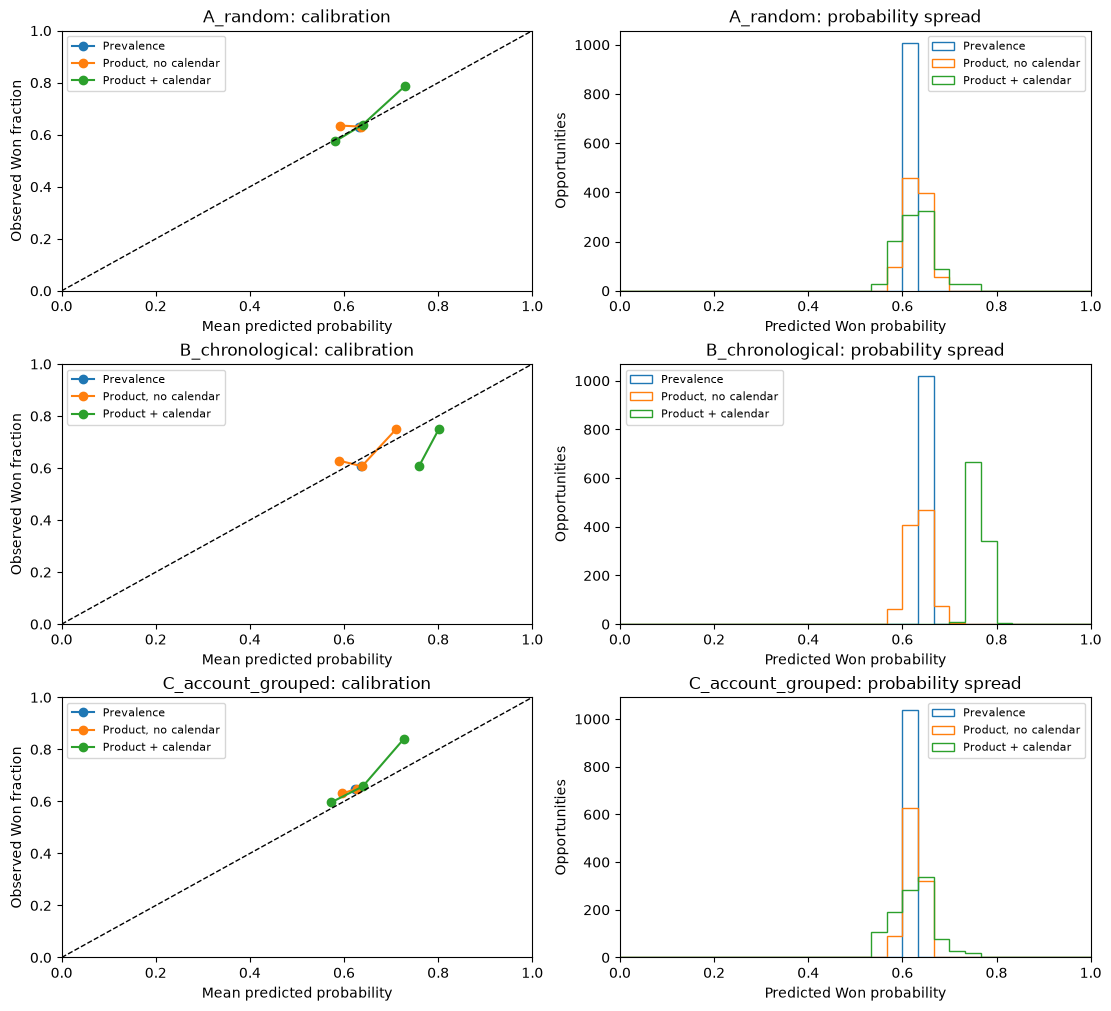

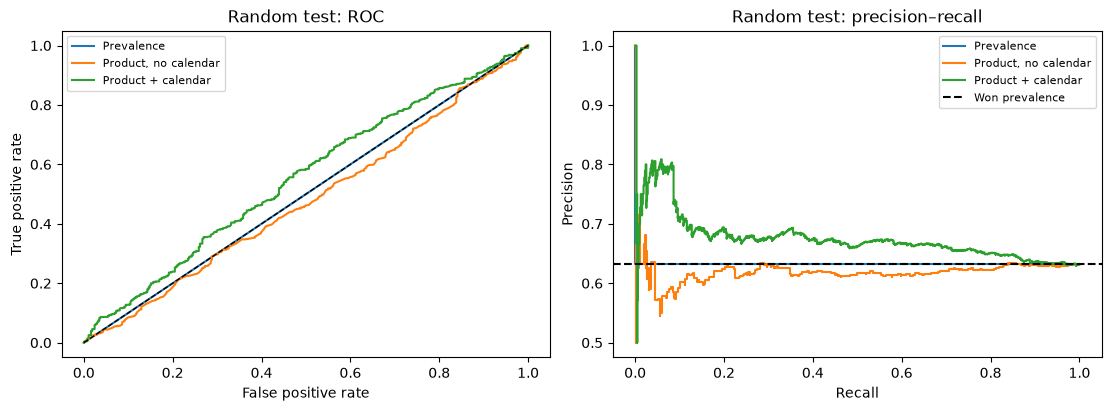

In [16]:
diagnostic_variants = {
    "Prevalence": ("Core", "Prevalence"),
    "Product, no calendar": ("Core + product", diagnostic_model),
    "Product + calendar": (calendar_name, diagnostic_model),
}
calibration_figure, axes = plt.subplots(3, 2, figsize=(11, 10), constrained_layout=True)
for row, (split_name, parts) in enumerate(splits.items()):
    for label, (feature_name, model_name) in diagnostic_variants.items():
        probability = results[(split_name, feature_name)]["probabilities"][model_name]["test"]
        bins = calibration_bins(y.loc[parts["test"]], probability)
        nonempty = bins.loc[bins["count"].gt(0)]
        axes[row, 0].plot(nonempty["mean_probability"], nonempty["won_fraction"], "o-", label=label)
        axes[row, 1].hist(probability, bins=np.linspace(0, 1, 31), histtype="step", label=label)
    axes[row, 0].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[row, 0].set(title=f"{split_name}: calibration", xlabel="Mean predicted probability", ylabel="Observed Won fraction", xlim=(0, 1), ylim=(0, 1))
    axes[row, 1].set(title=f"{split_name}: probability spread", xlabel="Predicted Won probability", ylabel="Opportunities", xlim=(0, 1))
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].legend(fontsize=8)
plt.show()

from sklearn.metrics import roc_curve
ranking_figure, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for label, (feature_name, model_name) in diagnostic_variants.items():
    probability = results[("A_random", feature_name)]["probabilities"][model_name]["test"]
    fpr, tpr, _ = roc_curve(y.loc[test_a], probability)
    precision, recall, _ = precision_recall_curve(y.loc[test_a], probability)
    axes[0].plot(fpr, tpr, label=label)
    axes[1].step(recall, precision, where="post", label=label)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].axhline(y.loc[test_a].mean(), color="black", linestyle="--", label="Won prevalence")
axes[0].set(title="Random test: ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Random test: precision–recall", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend(fontsize=8)
plt.show()

## 12. Which features appear useful? Could bands still identify accounts?
Permutation importance below is calculated on **validation**, not used to alter the features. It measures the drop in ROC-AUC after shuffling an original column, using the same learned model family chosen above. Near-zero or negative values do not support useful contribution. The reported standard deviation is variation across shuffles, **not a confidence interval**.

Employee/revenue bands and month/quarter are correlated; individual permutation importance can be misleading when columns substitute for each other or shuffled combinations become unrealistic. The feature-set comparison is the stronger group-level check. All importance is predictive association, not causation.

Removing names and exact numbers does not guarantee anonymity: combinations of sector, size, and subsidiary status may still uniquely describe an account. Count this risk explicitly without fitting an account identifier. The account-grouped evaluation is the substantive generalization check.

In [17]:
from sklearn.inspection import permutation_importance

importance_frames = []
for feature_name, columns in FEATURE_SETS.items():
    fitted_model = results[("A_random", feature_name)]["models"][diagnostic_model]
    importance = permutation_importance(
        fitted_model, features.loc[validation_a, columns], y.loc[validation_a],
        scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=2,
    )
    importance_frames.append(pd.DataFrame({
        "feature_set": feature_name, "feature": columns,
        "validation_AUC_drop": importance.importances_mean,
        "shuffle_std": importance.importances_std,
    }))
importance_table = pd.concat(importance_frames, ignore_index=True)
display(importance_table.sort_values(["feature_set", "validation_AUC_drop"], ascending=[True, False]).round(4))

profiles = features[CORE].join(metadata["account"]).drop_duplicates()
accounts_per_profile = profiles.groupby(CORE, dropna=False)["account"].nunique()
profile_audit = pd.Series({
    "accounts": profiles["account"].nunique(),
    "distinct_core_profiles": len(accounts_per_profile),
    "profiles_identifying_one_account": int(accounts_per_profile.eq(1).sum()),
    "fraction_of_accounts_uniquely_profiled": accounts_per_profile.eq(1).sum() / profiles["account"].nunique(),
}, name="value")
display(profile_audit.to_frame())

unknown_rows = []
for split_name, parts in splits.items():
    for partition in ["validation", "test"]:
        for column in features:
            fraction = (~features.loc[parts[partition], column].isin(features.loc[parts["train"], column])).mean()
            if fraction > 0:
                unknown_rows.append({"split": split_name, "partition": partition, "feature": column, "unseen_fraction": fraction})
unknown_categories = pd.DataFrame(unknown_rows)
print("Categories absent from training; encoded as all-zero, never learned from holdouts:")
display(unknown_categories.round(4))

,feature_set,feature,validation_AUC_drop,shuffle_std
3,Core,is_subsidiary,0.0032,0.0044
1,Core,employee_band,-0.0009,0.0107
2,Core,revenue_band,-0.0025,0.0126
0,Core,sector,-0.0159,0.0091
5,Core + product,employee_band,-0.0028,0.0062
8,Core + product,product,-0.0057,0.0194
7,Core + product,is_subsidiary,-0.0085,0.0036
6,Core + product,revenue_band,-0.0133,0.0048
4,Core + product,sector,-0.0170,0.0112
21,Core + product + assignment,sales_agent,0.0081,0.0141


,value
accounts,85.000000
distinct_core_profiles,54.000000
profiles_identifying_one_account,37.000000
fraction_of_accounts_uniquely_profiled,0.435294


Categories absent from training; encoded as all-zero, never learned from holdouts:


,split,partition,feature,unseen_fraction
0,B_chronological,validation,engagement_month,0.675


In [18]:
# Descriptive timing audit only: this table never supplies model features.
cohort_audit = pipeline.assign(
    engagement_period=pipeline["engage_date"].dt.to_period("Q"),
    is_closed=pipeline["deal_stage"].isin(["Won", "Lost"]),
    outcome=pipeline["deal_stage"].map({"Won": 1, "Lost": 0}),
).groupby("engagement_period", dropna=False).agg(
    all_opportunities=("is_closed", "size"),
    observed_closed=("is_closed", "sum"),
    closed_won_prevalence=("outcome", "mean"),
)
cohort_audit["still_open"] = cohort_audit["all_opportunities"] - cohort_audit["observed_closed"]
display(cohort_audit.round(4))
print("Different years/cohorts share month labels. This is not evidence of repeatable seasonality.")

,all_opportunities,observed_closed,closed_won_prevalence,still_open
engagement_period,,,,
2016Q4,358,305,0.8197,53
2017Q1,1619,1322,0.6793,297
2017Q2,2388,2022,0.6162,366
2017Q3,2770,2012,0.5999,758
2017Q4,1165,1050,0.6067,115
NaT,500,0,NaN,500


Different years/cohorts share month labels. This is not evidence of repeatable seasonality.


## 13. Final findings — three different questions
The first table reports the model chosen by **validation ROC-AUC, then Brier**, for each predeclared feature set and split. Selection by ranking alone does not guarantee better probability quality; always check the baseline Brier alongside it.

The second table compares the **same model family and feature set** across splits. Signed differences are `other split − random`: negative ROC-AUC/AP means a fall; positive Brier means worse probabilities. These are descriptive differences between different test populations, not paired causal effects. AP also changes with Won prevalence.

No seed, feature, model parameter, or cutoff is changed in response to these results.

In [19]:
selected_comparison = comparison.loc[comparison["selected_on_validation"]].drop(columns="selected_on_validation")
display(selected_comparison.round(4))

change_columns = ["ROC_AUC", "AP", "Brier", "Brier_skill", "Won_prevalence"]
random_reference = test_metrics.xs("A_random", level="split")[change_columns]
split_deltas = pd.concat({
    split_name: test_metrics.xs(split_name, level="split")[change_columns] - random_reference
    for split_name in ["B_chronological", "C_account_grouped"]
}, names=["split"]).add_prefix("delta_")
print("Same-family comparison:", diagnostic_model, "— changes relative to random test")
display(split_deltas.xs(diagnostic_model, level="model").round(4))

# Feature-group changes hold both the split and model family fixed.
feature_deltas = pd.concat({
    "add_product": test_metrics.xs("Core + product", level="feature_set")[change_columns]
                   - test_metrics.xs("Core", level="feature_set")[change_columns],
    "add_calendar_to_product": test_metrics.xs(calendar_name, level="feature_set")[change_columns]
                   - test_metrics.xs("Core + product", level="feature_set")[change_columns],
    "add_assignment_to_product": test_metrics.xs("Core + product + assignment", level="feature_set")[change_columns]
                   - test_metrics.xs("Core + product", level="feature_set")[change_columns],
}, names=["feature_change"]).add_prefix("delta_")
print("Feature-group changes (descriptive test comparisons, not feature selection):")
display(feature_deltas.xs(diagnostic_model, level="model").round(4))

val_ROC_AUC  \
split             feature_set                 model                        
A_random          Core                        Prevalence          0.5000   
                  Core + product              Prevalence          0.5000   
                  Core + product + assignment XGBoost             0.5047   
                  Core + product + calendar   Random Forest       0.5667   
B_chronological   Core                        Prevalence          0.5000   
                  Core + product              XGBoost             0.5007   
                  Core + product + assignment Prevalence          0.5000   
                  Core + product + calendar   Prevalence          0.5000   
C_account_grouped Core                        Prevalence          0.5000   
                  Core + product              Prevalence          0.5000   
                  Core + product + assignment Prevalence          0.5000   
                  Core + product + calendar   Random Forest       0.5403   

                                                             val_AP  \
split             feature_set                 model                   
A_random          Core                        Prevalence     0.6316   
                  Core + product              Prevalence     0.6316   
                  Core + product + assignment XGBoost        0.6406   
                  Core + product + calendar   Random Forest  0.6816   
B_chronological   Core                        Prevalence     0.6351   
                  Core + product              XGBoost        0.6350   
                  Core + product + assignment Prevalence     0.6351   
                  Core + product + calendar   Prevalence     0.6351   
C_account_grouped Core                        Prevalence     0.6443   
                  Core + product              Prevalence     0.6443   
                  Core + product + assignment Prevalence     0.6443   
                  Core + product + calendar   Random Forest  0.6775   

                                                             val_Brier  \
split             feature_set                 model                      
A_random          Core                        Prevalence        0.2327   
                  Core + product              Prevalence        0.2327   
                  Core + product + assignment XGBoost           0.2354   
                  Core + product + calendar   Random Forest     0.2303   
B_chronological   Core                        Prevalence        0.2317   
                  Core + product              XGBoost           0.2338   
                  Core + product + assignment Prevalence        0.2317   
                  Core + product + calendar   Prevalence        0.2317   
C_account_grouped Core                        Prevalence        0.2296   
                  Core + product              Prevalence        0.2296   
                  Core + product + assignment Prevalence        0.2296   
                  Core + product + calendar   Random Forest     0.2287   

                                                             ROC_AUC      AP  \
split             feature_set                 model                            
A_random          Core                        Prevalence      0.5000  0.6316   
                  Core + product              Prevalence      0.5000  0.6316   
                  Core + product + assignment XGBoost         0.4856  0.6293   
                  Core + product + calendar   Random Forest   0.5533  0.6758   
B_chronological   Core                        Prevalence      0.5000  0.6090   
                  Core + product              XGBoost         0.4791  0.6063   
                  Core + product + assignment Prevalence      0.5000  0.6090   
                  Core + product + calendar   Prevalence      0.5000  0.6090   
C_account_grouped Core                        Prevalence      0.5000  0.6477   
                  Core + product              Prevalence      0.5000  0.6477   
    

Same-family comparison: Random Forest — changes relative to random test


delta_ROC_AUC  delta_AP  \
split             feature_set                                            
B_chronological   Core                                0.0123    0.0009   
                  Core + product                     -0.0011   -0.0214   
                  Core + product + assignment         0.0212   -0.0164   
                  Core + product + calendar          -0.0174   -0.0191   
C_account_grouped Core                                0.0520    0.0513   
                  Core + product                      0.0488    0.0522   
                  Core + product + assignment         0.0061    0.0092   
                  Core + product + calendar           0.0234    0.0390   

                                               delta_Brier  delta_Brier_skill  \
split             feature_set                                                   
B_chronological   Core                              0.0048             0.0059   
                  Core + product                    0.0059             0.0011   
                  Core + product + assignment       0.0057             0.0020   
                  Core + product + calendar         0.0288            -0.0952   
C_account_grouped Core                             -0.0064             0.0104   
                  Core + product                   -0.0056             0.0073   
                  Core + product + assignment      -0.0040             0.0000   
                  Core + product + calendar        -0.0055             0.0071   

                                               delta_Won_prevalence  
split             feature_set                                        
B_chronological   Core                                      -0.0225  
                  Core + product                            -0.0225  
                  Core + product + assignment               -0.0225  
                  Core + product + calendar                 -0.0225  
C_account_grouped Core                                       0.0162  
                  Core + product                             0.0162  
                  Core + product + assignment                0.0162  
                  Core + product + calendar                  0.0162

Feature-group changes (descriptive test comparisons, not feature selection):


delta_ROC_AUC  delta_AP  \
feature_change            split                                        
add_product               A_random                  0.0036    0.0038   
                          B_chronological          -0.0099   -0.0185   
                          C_account_grouped         0.0004    0.0047   
add_calendar_to_product   A_random                  0.0746    0.0558   
                          B_chronological           0.0583    0.0581   
                          C_account_grouped         0.0491    0.0426   
add_assignment_to_product A_random                  0.0155    0.0163   
                          B_chronological           0.0378    0.0213   
                          C_account_grouped        -0.0272   -0.0267   

                                             delta_Brier  delta_Brier_skill  \
feature_change            split                                               
add_product               A_random               -0.0006             0.0027   
                          B_chronological         0.0005            -0.0020   
                          C_account_grouped       0.0001            -0.0004   
add_calendar_to_product   A_random               -0.0031             0.0133   
                          B_chronological         0.0198            -0.0829   
                          C_account_grouped      -0.0030             0.0131   
add_assignment_to_product A_random               -0.0010             0.0043   
                          B_chronological        -0.0012             0.0052   
                          C_account_grouped       0.0007            -0.0029   

                                             delta_Won_prevalence  
feature_change            split                                    
add_product               A_random                            0.0  
                          B_chronological                     0.0  
                          C_account_grouped                   0.0  
add_calendar_to_product   A_random                            0.0  
                          B_chronological                     0.0  
                          C_account_grouped                   0.0  
add_assignment_to_product A_random                            0.0  
                          B_chronological                     0.0  
                          C_account_grouped                   0.0

In [20]:
random_comparison = comparison.loc["A_random"].reset_index()
general = random_comparison.loc[
    random_comparison["feature_set"].isin(["Core", "Core + product"])
    & random_comparison["model"].ne("Prevalence")
]
baseline = results[("A_random", "Core")]["test"].loc["Prevalence"]
validation_baseline = results[("A_random", "Core")]["validation"].loc["Prevalence"]
general_improves = (
    general["val_ROC_AUC"].gt(0.5) & general["ROC_AUC"].gt(0.5)
    & general["val_AP"].gt(validation_baseline["AP"]) & general["AP"].gt(baseline["AP"])
    & general["val_Brier"].lt(validation_baseline["Brier"]) & general["Brier"].lt(baseline["Brier"])
)
best_random = random_comparison.loc[random_comparison["model"].ne("Prevalence")].sort_values(
    ["val_ROC_AUC", "val_Brier"], ascending=[False, True],
).iloc[0]
chronological_change = split_deltas.loc[("B_chronological", calendar_name, diagnostic_model)]
account_change = split_deltas.loc[("C_account_grouped", calendar_name, diagnostic_model)]
calendar_tests = test_metrics.xs((calendar_name, diagnostic_model), level=("feature_set", "model"))
strongest_split = calendar_tests["ROC_AUC"].idxmax()
decision = (
    "Some general-feature signal detected; assess its magnitude and replicate before continuing."
    if general_improves.any() else
    "RECONSIDER MAVEN for general-characteristic Won/Lost prediction: the clean random baseline is near chance."
)
findings = [
    f"Population: {len(y):,} closed opportunities; {int(y.sum()):,} Won; {int(y.eq(0).sum()):,} Lost; prevalence {y.mean():.2%}.",
    f"A — general features: {int(general_improves.sum())}/{len(general)} learned candidates beat prevalence on ranking and Brier in BOTH validation and test.",
    f"General-feature random test AUC range: {general['ROC_AUC'].min():.4f}–{general['ROC_AUC'].max():.4f}; prevalence Brier {baseline['Brier']:.4f}.",
    f"Core and Core + product each select {results[('A_random', 'Core')]['selected']} / {results[('A_random', 'Core + product')]['selected']} on random validation.",
    f"Best learned random-validation candidate: {best_random['model']} / {best_random['feature_set']}; test AUC {best_random['ROC_AUC']:.4f}, AP {best_random['AP']:.4f} (prevalence {baseline['Won_prevalence']:.4f}), Brier {best_random['Brier']:.4f}, skill {best_random['Brier_skill']:.2%}.",
    f"B — same calendar model vs random: AUC {chronological_change['delta_ROC_AUC']:+.4f}, AP {chronological_change['delta_AP']:+.4f}, Brier {chronological_change['delta_Brier']:+.4f}. Later-period probability improvement is not supported.",
    f"C — same calendar model vs random: AUC {account_change['delta_ROC_AUC']:+.4f}, AP {account_change['delta_AP']:+.4f}, Brier {account_change['delta_Brier']:+.4f}. No grouped-performance fall here; only 13 test accounts.",
    f"Strongest observed calendar-family test: {strongest_split}, AUC {calendar_tests.loc[strongest_split, 'ROC_AUC']:.4f}; different composition, not a new model choice.",
    "Useful association: engagement month/quarter; no convincing general-company/product or assignment signal. Calendar association is not demonstrated seasonality.",
    "Keep excluded: outcomes/closing fields, identifiers, exact account financials, parent names, history; calendar and assignment stay outside the primary feature contract.",
    decision,
]
print("\n\n".join(findings))

Population: 6,711 closed opportunities; 4,238 Won; 2,473 Lost; prevalence 63.15%.

A — general features: 0/6 learned candidates beat prevalence on ranking and Brier in BOTH validation and test.

General-feature random test AUC range: 0.4752–0.4921; prevalence Brier 0.2327.

Core and Core + product each select Prevalence / Prevalence on random validation.

Best learned random-validation candidate: Random Forest / Core + product + calendar; test AUC 0.5533, AP 0.6758 (prevalence 0.6316), Brier 0.2308, skill 0.82%.

B — same calendar model vs random: AUC -0.0174, AP -0.0191, Brier +0.0288. Later-period probability improvement is not supported.

C — same calendar model vs random: AUC +0.0234, AP +0.0390, Brier -0.0055. No grouped-performance fall here; only 13 test accounts.

Strongest observed calendar-family test: C_account_grouped, AUC 0.5766; different composition, not a new model choice.

Useful association: engagement month/quarter; no convincing general-company/product or assignment

### Interpretation and limits
**Current recommendation: reconsider Maven for a general-characteristic opportunity model.** This follows the clean random experiment, not only the old strict chronological result. Core and product-enriched learned models are near chance and do not improve Brier over prevalence. More tuning or outcome-history engineering is not justified by this baseline.

Calendar information has a modest association with outcomes in random and account-grouped splits, but it does not establish useful future-period probabilities. The engagement audit shows **2016 Q4 closed opportunities have about 82% Won**, versus **61% in 2017 Q4**; shared month/quarter labels do not imply stable seasonality. Chronological training sees late-year months mainly from the earlier cohort, and the calendar models overpredict later wins. Brier exposes this even where ROC-AUC remains slightly above 0.5.

Account separation does **not** cause the expected performance collapse in this run. That does not prove company-invariant performance: only 85 accounts exist, just 13 are in the grouped test, and **37 of 85 accounts still have unique coarse profiles**. Do not interpret small differences as significant.

Limits: one fixed split per strategy; no confidence intervals or independent replication; already-inspected fictitious dataset; undated reference attributes; unresolved-deal selection; and 983 training / 758 validation labels not yet observed at the chronological boundaries. No faithful prospective backtest or real-world effectiveness claim follows. These results show **insufficient defensible general-feature signal in the tested baselines**, not a proof that every possible Maven model must fail.

## 14. Save the evidence and verify the contract
Exports use a new `v1` results directory. Re-running this notebook refreshes **only this notebook's own exports**; all earlier notebooks, results, and input CSVs remain unchanged. Save source hashes, package versions, fixed model settings, feature contract, partition assignments, all metrics, thresholds, and diagnostics. Opportunity IDs in the partition audit are metadata only, not model inputs.

In [21]:
assert len(results) == len(splits) * len(FEATURE_SETS)
assert len(all_metrics) == len(results) * len(MODELS) * 2
for (split_name, feature_name), result in results.items():
    parts = splits[split_name]
    assert set(np.concatenate(list(parts.values()))) == set(y.index)
    for model_name, model in result["models"].items():
        assert list(model.feature_names_in_) == result["features"]
        encoder = model.named_steps["onehotencoder"]
        for column, levels in zip(result["features"], encoder.categories_):
            assert set(levels) == set(features.loc[parts["train"], column].fillna("missing"))
        for partition, probability in result["probabilities"][model_name].items():
            assert len(probability) == len(parts[partition])
            assert np.isfinite(probability).all() and ((probability >= 0) & (probability <= 1)).all()
            assert np.asarray(result[partition].loc[model_name, "confusion_matrix"]).sum() == len(probability)
            if model_name == "Prevalence":
                np.testing.assert_allclose(probability, y.loc[parts["train"]].mean())

assert source_hashes == {name: hashlib.sha256((DATA / f"{name}.csv").read_bytes()).hexdigest() for name in names}
assert previous_hashes == {name: hashlib.sha256((ROOT / "notebooks" / name).read_bytes()).hexdigest() for name in previous_files}
print("Passed: one opportunity per row; split/group/date disjointness; train-only encoding; 48 fitted candidates;")
print("96 metric rows; valid probabilities/confusion matrices; training-only prevalence; unchanged inputs and previous results.")

Passed: one opportunity per row; split/group/date disjointness; train-only encoding; 48 fitted candidates;
96 metric rows; valid probabilities/confusion matrices; training-only prevalence; unchanged inputs and previous results.


In [23]:
RUN_OUTPUT = OUTPUT / "v1"
RUN_OUTPUT.mkdir(parents=True, exist_ok=True)
assignments = pd.concat([
    metadata.loc[index].assign(target=y.loc[index], split=split_name, partition=partition)
    for split_name, parts in splits.items() for partition, index in parts.items()
], ignore_index=True)
exports = {
    "metrics": all_metrics,
    "comparison": comparison.reset_index(),
    "threshold_comparison": threshold_comparison.reset_index(),
    "probability_ranges": probability_ranges.reset_index(),
    "calibration": calibration_table,
    "feature_contract": feature_contract,
    "split_summary": pd.concat(split_tables, names=["split"]).reset_index(),
    "split_assignments": assignments,
    "split_deltas": split_deltas.reset_index(),
    "feature_deltas": feature_deltas.reset_index(),
    "validation_importance": importance_table,
    "label_timing": label_timing,
    "cohort_audit": cohort_audit.reset_index(),
    "unknown_categories": unknown_categories,
}
for name, table in exports.items():
    table.to_csv(RUN_OUTPUT / f"{name}.csv", index=False)
calibration_figure.savefig(RUN_OUTPUT / "calibration.png", dpi=130, bbox_inches="tight")
ranking_figure.savefig(RUN_OUTPUT / "ranking.png", dpi=130, bbox_inches="tight")

model_parameters = {name: model.get_params() for name, model in MODELS.items()}
model_parameters["XGBoost"]["missing"] = "NaN (default missing-value sentinel)"  # Valid JSON, not bare NaN.
report = {
    "seed": SEED, "python": sys.version.split()[0], "packages": packages,
    "population": population, "input_sha256": source_hashes,
    "preserved_previous_sha256": previous_hashes,
    "feature_sets": FEATURE_SETS, "feature_contract": feature_contract.to_dict("records"),
    "model_parameters": model_parameters,
    "selection": "validation ROC-AUC descending, Brier ascending; no test selection",
    "threshold_rule": "maximum validation F1; highest threshold on ties",
    "chronological_validation_start": str(validation_start.date()),
    "chronological_test_start": str(test_start.date()),
    "chronological_interpretation": "retrospective engagement cohorts, not an as-of-label backtest",
    "profile_audit": profile_audit.to_dict(), "findings": findings,
}
(RUN_OUTPUT / "summary.json").write_text(json.dumps(report, indent=2, default=str, allow_nan=False) + "\n")
print("Saved evidence to:", RUN_OUTPUT.relative_to(ROOT))

Saved evidence to: notebooks/maven_simple_results/v1
